# Level 1
# Task 1

In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv(r"C:\Users\Lenovo\Documents\Internship_Project\Dataset\Datafile.csv")

# Split multiple cuisines into separate rows
cuisines = (
    df["Cuisines"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)

# Top 3 cuisines
top3 = cuisines.value_counts().head(3)

# Percentage calculation
percentage = (top3 / len(df)) * 100

print(top3)
print(percentage.round(2))

Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64
Cuisines
North Indian    41.46
Chinese         28.64
Fast Food       20.79
Name: count, dtype: float64


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Improve graph appearance
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [4]:
# Load dataset
df = pd.read_csv(r"C:\Users\Lenovo\Documents\Internship_Project\Dataset\Datafile.csv")

# Display first five rows
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [5]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print(df.columns)

# Dataset information
df.info()

Dataset Shape: (9551, 21)
Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7 

In [6]:
# Missing values in each column
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [7]:
# Remove rows where cuisine is missing
df = df.dropna(subset=["Cuisines"])

In [8]:
# Split multiple cuisines into individual rows
all_cuisines = (
    df["Cuisines"]
    .str.split(",")
    .explode()
    .str.strip()
)

In [9]:
# Count frequency of every cuisine
cuisine_counts = all_cuisines.value_counts()

cuisine_counts.head(10)

Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Mughlai          995
Italian          764
Bakery           745
Continental      736
Cafe             703
Desserts         653
South Indian     636
Name: count, dtype: int64

In [10]:
top3 = cuisine_counts.head(3)

print(top3)

Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64


In [11]:
total_restaurants = len(df)

percentage = round((top3 / total_restaurants) * 100, 2)

percentage

Cuisines
North Indian    41.50
Chinese         28.66
Fast Food       20.81
Name: count, dtype: float64

In [12]:
result = pd.DataFrame({
    "Cuisine": top3.index,
    "Restaurant Count": top3.values,
    "Percentage (%)": percentage.values
})

result

,Cuisine,Restaurant Count,Percentage (%)
0,North Indian,3960,41.50
1,Chinese,2735,28.66
2,Fast Food,1986,20.81


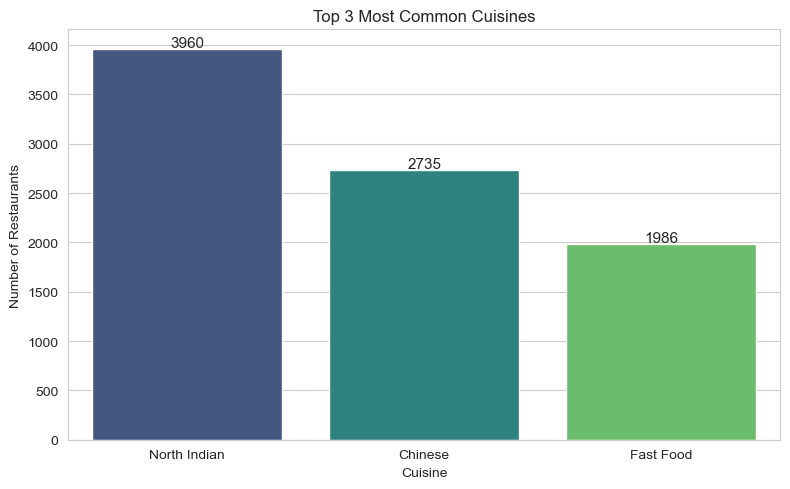

In [13]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=result,
    x="Cuisine",
    y="Restaurant Count",
    hue="Cuisine",
    palette="viridis",
    legend=False
)

plt.title("Top 3 Most Common Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")

# Add value labels
for index, value in enumerate(result["Restaurant Count"]):
    plt.text(index, value+20, str(value), ha='center', fontsize=11)

plt.tight_layout()

plt.savefig(
    r"C:\Users\Lenovo\Documents\Internship_Project\Images\Task1_Top_Cuisines.png",
    dpi=300
)

plt.show()

In [14]:
print("="*50)
print("TOP 3 MOST COMMON CUISINES")
print("="*50)

for cuisine, count in top3.items():
    percent = (count/total_restaurants)*100
    print(f"{cuisine:<20} {count:>5} Restaurants ({percent:.2f}%)")

TOP 3 MOST COMMON CUISINES
North Indian          3960 Restaurants (41.50%)
Chinese               2735 Restaurants (28.66%)
Fast Food             1986 Restaurants (20.81%)


# Conclusion

- The dataset was analyzed to identify the most common cuisines served by restaurants.
- Multiple cuisines were separated into individual entries using the `explode()` function.
- The top three cuisines were identified based on their frequency.
- The percentage of restaurants serving each of the top cuisines was calculated.
- A bar chart was created to visualize the distribution of the top three cuisines.

# Task 2

In [15]:
# Required columns
df[['City', 'Aggregate rating']].head()

,City,Aggregate rating
0,Makati City,4.8
1,Makati City,4.5
2,Mandaluyong City,4.4
3,Mandaluyong City,4.9
4,Mandaluyong City,4.8


In [16]:
# Count restaurants in each city
city_restaurant_count = (
    df['City']
    .value_counts()
    .reset_index(name='Restaurant Count')
    .rename(columns={'City': 'City'})
)

city_restaurant_count.head()

,City,Restaurant Count
0,New Delhi,5473
1,Gurgaon,1118
2,Noida,1080
3,Faridabad,251
4,Ghaziabad,25


In [17]:
# City with the highest number of restaurants
top_city = city_restaurant_count.iloc[0]

print("City with Highest Number of Restaurants")
print("-" * 40)
print(f"City: {top_city['City']}")
print(f"Restaurant Count: {top_city['Restaurant Count']}")

City with Highest Number of Restaurants
----------------------------------------
City: New Delhi
Restaurant Count: 5473


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17280\1351594527.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


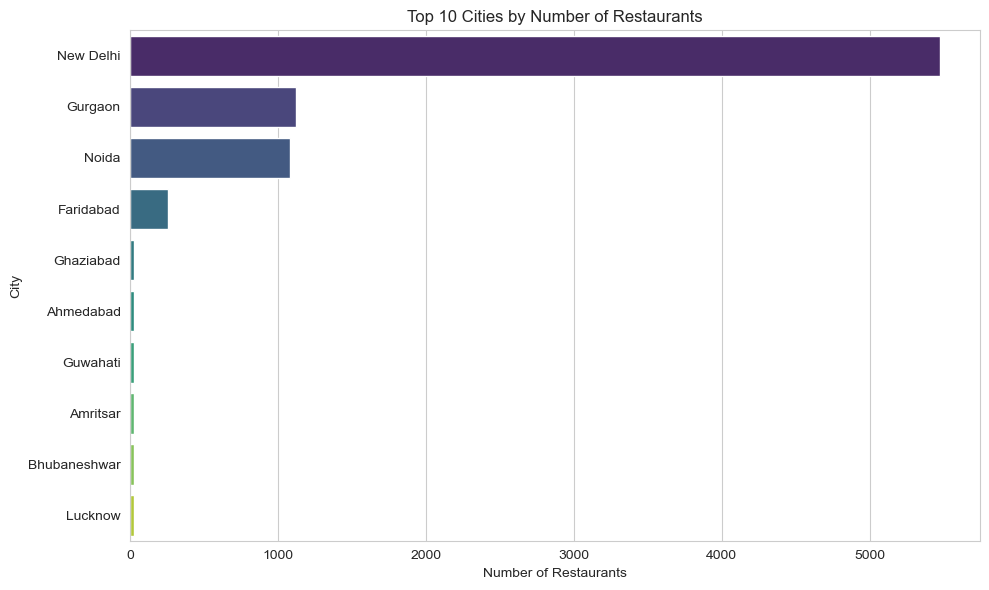

In [18]:
top10 = city_restaurant_count.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Restaurant Count",
    y="City",
    palette="viridis"
)

plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("City")

plt.tight_layout()

plt.savefig(
    r"C:\Users\Lenovo\Documents\Internship_Project\Images\Task2_Top10_Cities.png",
    dpi=300
)

plt.show()

In [19]:
city_rating = (
    df.groupby('City')['Aggregate rating']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

city_rating.columns = ['City', 'Average Rating']

city_rating.head(10)

,City,Average Rating
0,Inner City,4.900000
1,Quezon City,4.800000
2,Makati City,4.650000
3,Pasig City,4.633333
4,Mandaluyong City,4.625000
5,Beechworth,4.600000
6,London,4.535000
7,Taguig City,4.525000
8,Tagaytay City,4.500000
9,Secunderabad,4.500000


In [20]:
highest_rating_city = city_rating.iloc[0]

print("City with Highest Average Rating")
print("--------------------------------")
print(f"City : {highest_rating_city['City']}")
print(f"Average Rating : {highest_rating_city['Average Rating']:.2f}")

City with Highest Average Rating
--------------------------------
City : Inner City
Average Rating : 4.90


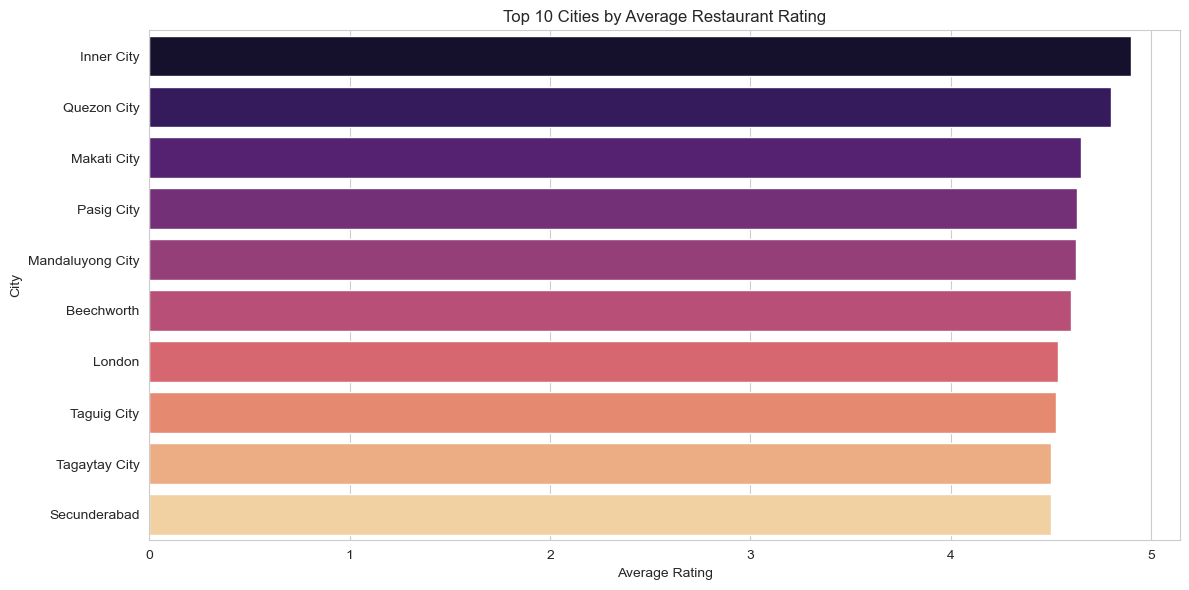

In [21]:
top10_rating = city_rating.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_rating,
    x='Average Rating',
    y='City',
    hue='City',
    palette='magma',
    legend=False
)

plt.title("Top 10 Cities by Average Restaurant Rating")
plt.xlabel("Average Rating")
plt.ylabel("City")

plt.tight_layout()

plt.savefig(
    r"C:\Users\Lenovo\Documents\Internship_Project\Images\Task2_Highest_Rating_Cities.png",
    dpi=300
)

plt.show()

In [22]:
print("="*60)
print("TOP 10 CITIES BY RESTAURANT COUNT")
print("="*60)

print(city_restaurant_count.head(10))

print("\n")

print("="*60)
print("TOP 10 CITIES BY AVERAGE RATING")
print("="*60)

print(city_rating.head(10))

TOP 10 CITIES BY RESTAURANT COUNT
           City  Restaurant Count
0     New Delhi              5473
1       Gurgaon              1118
2         Noida              1080
3     Faridabad               251
4     Ghaziabad                25
5     Ahmedabad                21
6      Guwahati                21
7      Amritsar                21
8  Bhubaneshwar                21
9       Lucknow                21


TOP 10 CITIES BY AVERAGE RATING
               City  Average Rating
0        Inner City        4.900000
1       Quezon City        4.800000
2       Makati City        4.650000
3        Pasig City        4.633333
4  Mandaluyong City        4.625000
5        Beechworth        4.600000
6            London        4.535000
7       Taguig City        4.525000
8     Tagaytay City        4.500000
9      Secunderabad        4.500000


# Conclusion

- The restaurant data was grouped by city to determine the number of restaurants in each location.
- The city with the highest number of restaurants was identified.
- The average restaurant rating was calculated for every city using the Aggregate rating column.
- The city with the highest average rating was determined.
- Two bar charts were created:
  - Top 10 cities by restaurant count.
  - Top 10 cities by average restaurant rating.
- The visualizations help compare restaurant distribution and customer ratings across cities.

# Task 3

In [23]:
# Display unique values
print(df["Price range"].unique())

# Count of each price range
df["Price range"].value_counts().sort_index()

[3 4 2 1]


Price range
1    4438
2    3113
3    1405
4     586
Name: count, dtype: int64

In [24]:
price_distribution = (
    df["Price range"]
    .value_counts()
    .sort_index()
    .reset_index()
)

price_distribution.columns = ["Price Range", "Restaurant Count"]

price_distribution

,Price Range,Restaurant Count
0,1,4438
1,2,3113
2,3,1405
3,4,586


In [25]:
total_restaurants = len(df)

price_distribution["Percentage (%)"] = (
    price_distribution["Restaurant Count"] / total_restaurants * 100
).round(2)

price_distribution

,Price Range,Restaurant Count,Percentage (%)
0,1,4438,46.51
1,2,3113,32.62
2,3,1405,14.72
3,4,586,6.14


In [26]:
print("=" * 50)
print("PRICE RANGE DISTRIBUTION")
print("=" * 50)

print(price_distribution)

PRICE RANGE DISTRIBUTION
   Price Range  Restaurant Count  Percentage (%)
0            1              4438           46.51
1            2              3113           32.62
2            3              1405           14.72
3            4               586            6.14


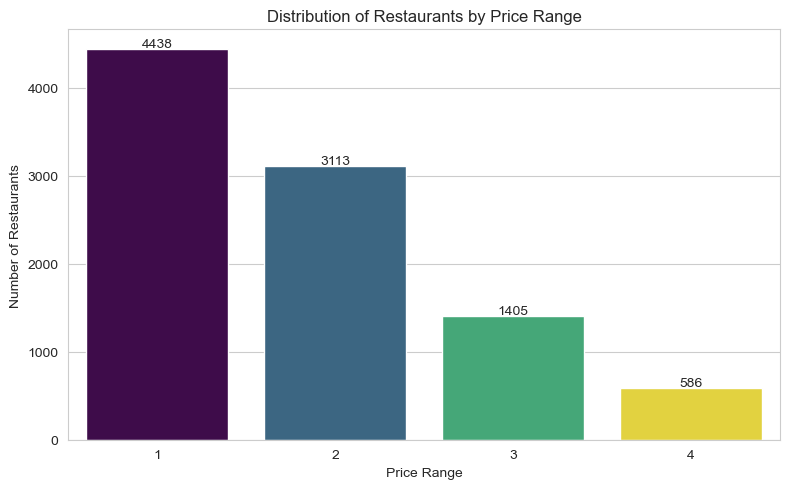

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=price_distribution,
    x="Price Range",
    y="Restaurant Count",
    hue="Price Range",
    palette="viridis",
    legend=False
)

plt.title("Distribution of Restaurants by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")

# Add labels
for index, value in enumerate(price_distribution["Restaurant Count"]):
    plt.text(index, value + 20, str(value), ha='center')

plt.tight_layout()

plt.savefig(
    r"C:\Users\Lenovo\Documents\Internship_Project\Images\Task3_Price_Range_Distribution.png",
    dpi=300
)

plt.show()

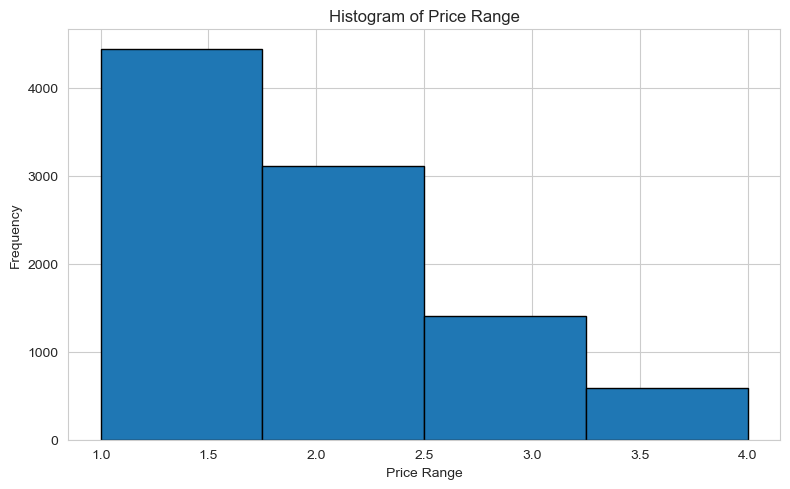

In [28]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Price range"],
    bins=4,
    edgecolor="black"
)

plt.title("Histogram of Price Range")
plt.xlabel("Price Range")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    r"C:\Users\Lenovo\Documents\Internship_Project\Images\Task3_Price_Range_Histogram.png",
    dpi=300
)

plt.show()

## Conclusion

- The distribution of restaurants across different price ranges was analyzed.
- The number of restaurants in each price range category was calculated.
- The percentage of restaurants belonging to each price range was computed.
- A bar chart was created to visualize the distribution of restaurants across all price range categories.
- The visualization helps identify which price range is most common in the dataset.

# Task 4

In [29]:
# Check unique values
print(df["Has Online delivery"].unique())

# Count restaurants
df["Has Online delivery"].value_counts()

['No' 'Yes']


Has Online delivery
No     7091
Yes    2451
Name: count, dtype: int64

In [30]:
online_delivery = (
    df["Has Online delivery"]
    .value_counts()
    .reset_index()
)

online_delivery.columns = ["Online Delivery", "Restaurant Count"]

online_delivery["Percentage (%)"] = (
    online_delivery["Restaurant Count"] / len(df) * 100
).round(2)

online_delivery

,Online Delivery,Restaurant Count,Percentage (%)
0,No,7091,74.31
1,Yes,2451,25.69


In [31]:
print("=" * 50)
print("ONLINE DELIVERY ANALYSIS")
print("=" * 50)

print(online_delivery)

ONLINE DELIVERY ANALYSIS
  Online Delivery  Restaurant Count  Percentage (%)
0              No              7091           74.31
1             Yes              2451           25.69


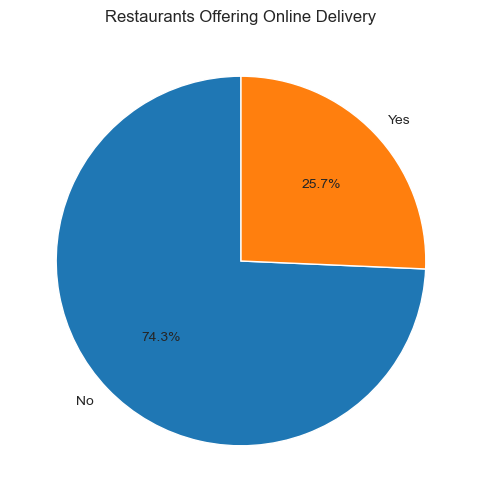

In [32]:
plt.figure(figsize=(6,6))

plt.pie(
    online_delivery["Restaurant Count"],
    labels=online_delivery["Online Delivery"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Restaurants Offering Online Delivery")

plt.savefig(
    r"C:\Users\Lenovo\Documents\Internship_Project\Images\Task4_Online_Delivery_Pie.png",
    dpi=300
)

plt.show()

In [33]:
average_rating = (
    df.groupby("Has Online delivery")["Aggregate rating"]
    .mean()
    .reset_index()
)

average_rating.columns = ["Online Delivery", "Average Rating"]

average_rating

,Online Delivery,Average Rating
0,No,2.463517
1,Yes,3.248837


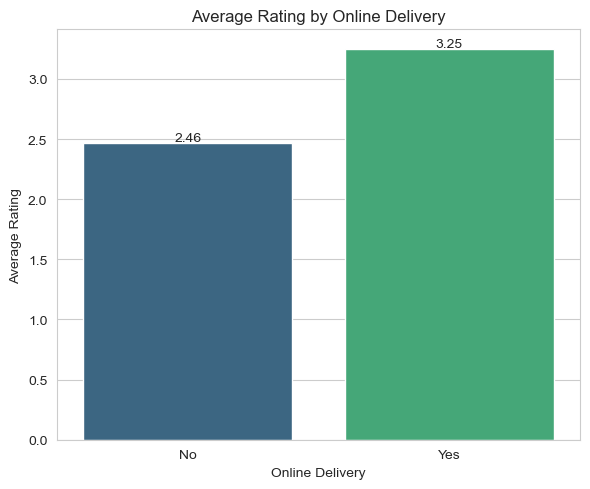

In [34]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=average_rating,
    x="Online Delivery",
    y="Average Rating",
    hue="Online Delivery",
    palette="viridis",
    legend=False
)

plt.title("Average Rating by Online Delivery")
plt.xlabel("Online Delivery")
plt.ylabel("Average Rating")

# Add value labels
for index, value in enumerate(average_rating["Average Rating"]):
    plt.text(index, value + 0.02, f"{value:.2f}", ha="center")

plt.tight_layout()

plt.savefig(
    r"C:\Users\Lenovo\Documents\Internship_Project\Images\Task4_Average_Rating_Online_Delivery.png",
    dpi=300
)

plt.show()

In [35]:
print("=" * 60)
print("AVERAGE RATING BASED ON ONLINE DELIVERY")
print("=" * 60)

print(average_rating)

AVERAGE RATING BASED ON ONLINE DELIVERY
  Online Delivery  Average Rating
0              No        2.463517
1             Yes        3.248837


# Conclusion

- The availability of online delivery services was analyzed.
- The percentage of restaurants offering online delivery was calculated.
- Restaurants were grouped based on whether they provide online delivery.
- The average aggregate rating was calculated for both groups.
- A pie chart was created to show the proportion of restaurants with and without online delivery.
- A bar chart was used to compare the average ratings of restaurants based on online delivery availability.

# Level 2
# Task 1

In [36]:
import os

base_path = r"C:\Users\Lenovo\Documents\Internship_Project\Images"

os.makedirs(os.path.join(base_path, "Level_2"), exist_ok=True)
os.makedirs(os.path.join(base_path, "Level_3"), exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [37]:
# Display first few values
df[['Aggregate rating', 'Votes']].head()

,Aggregate rating,Votes
0,4.8,314
1,4.5,591
2,4.4,270
3,4.9,365
4,4.8,229


In [38]:
# ==========================================================
# Summary statistics of Aggregate Rating
# ==========================================================

df['Aggregate rating'].describe()

count    9542.000000
mean        2.665238
std         1.516588
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64

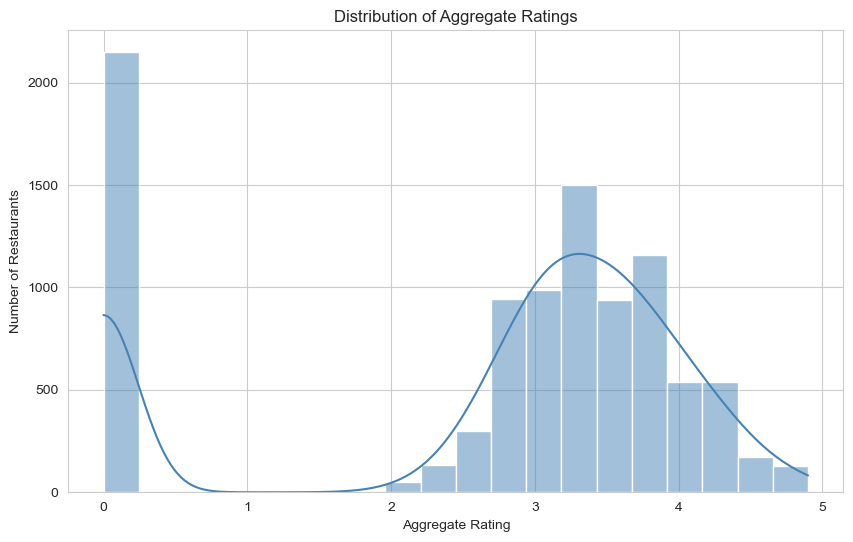

In [39]:
# ==========================================================
# Plot Distribution of Aggregate Ratings
# ==========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['Aggregate rating'],
    bins=20,
    kde=True,
    color='steelblue'
)

plt.title("Distribution of Aggregate Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")

plt.savefig(
    r"C:\Users\Lenovo\Documents\Internship_Project\Images\Level_2\Task1_Rating_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [40]:
# ==========================================================
# Group ratings into ranges
# ==========================================================

rating_bins = [0, 1, 2, 3, 4, 5]

rating_labels = [
    "0-1",
    "1-2",
    "2-3",
    "3-4",
    "4-5"
]

df['Rating Range'] = pd.cut(
    df['Aggregate rating'],
    bins=rating_bins,
    labels=rating_labels,
    include_lowest=True
)

rating_range = (
    df['Rating Range']
      .value_counts()
      .sort_index()
)

print(rating_range)

Rating Range
0-1    2148
1-2      10
2-3    1891
3-4    4381
4-5    1112
Name: count, dtype: int64


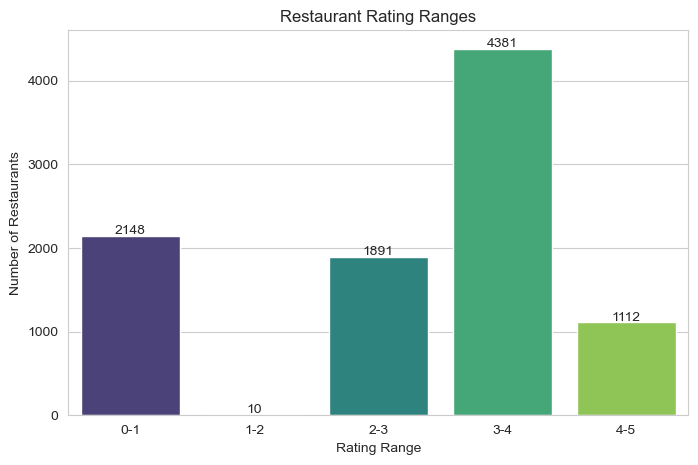

In [41]:
# ==========================================================
# Bar Chart of Rating Ranges
# ==========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    x=rating_range.index.astype(str),
    y=rating_range.values,
    hue=rating_range.index.astype(str),
    palette="viridis",
    legend=False
)

plt.title("Restaurant Rating Ranges")
plt.xlabel("Rating Range")
plt.ylabel("Number of Restaurants")

for i, value in enumerate(rating_range.values):
    plt.text(i, value+20, str(value), ha='center')

plt.savefig(
    r"C:\Users\Lenovo\Documents\Internship_Project\Images\Level_2\Task1_Rating_Range.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
# ==========================================================
# Most Common Rating Range
# ==========================================================

most_common = rating_range.idxmax()
count = rating_range.max()

print(f"Most Common Rating Range : {most_common}")
print(f"Number of Restaurants   : {count}")

Most Common Rating Range : 3-4
Number of Restaurants   : 4381


In [43]:
# ==========================================================
# Calculate Average Votes
# ==========================================================

average_votes = df['Votes'].mean()

print(f"Average Votes Received : {average_votes:.2f}")

Average Votes Received : 156.77


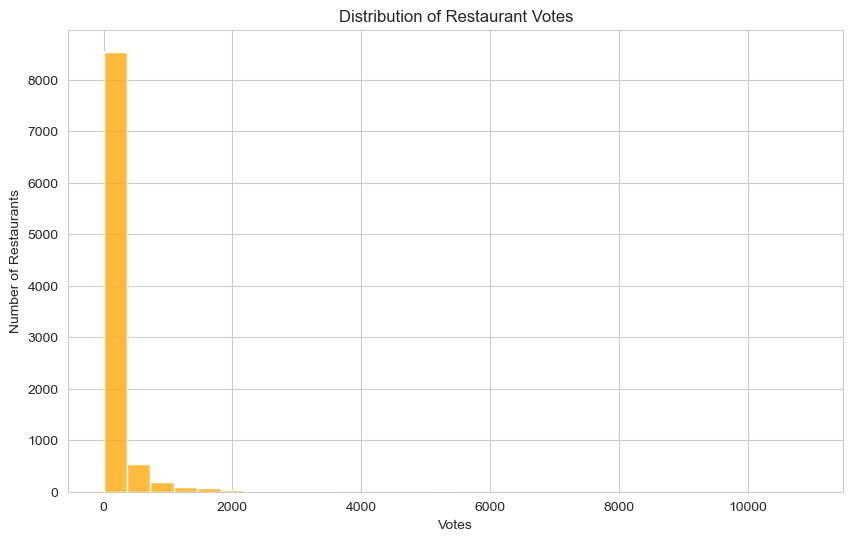

In [44]:
# ==========================================================
# Distribution of Votes
# ==========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['Votes'],
    bins=30,
    color="orange"
)

plt.title("Distribution of Restaurant Votes")
plt.xlabel("Votes")
plt.ylabel("Number of Restaurants")

plt.savefig(
    r"C:\Users\Lenovo\Documents\Internship_Project\Images\Level_2\Task1_Average_Votes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [45]:
# ==========================================================
# Final Results
# ==========================================================

print("="*50)
print("Restaurant Rating Analysis")
print("="*50)

print(f"Most Common Rating Range : {most_common}")
print(f"Average Votes           : {average_votes:.2f}")

Restaurant Rating Analysis
Most Common Rating Range : 3-4
Average Votes           : 156.77


## Conclusion

- The distribution of restaurant ratings was analyzed using a histogram.
- Restaurants were grouped into rating ranges from 0–1 to 4–5.
- The most common rating range was identified based on the highest frequency.
- The average number of votes received by restaurants was calculated.
- Two visualizations were created:
  - Distribution of Aggregate Ratings
  - Distribution of Restaurant Votes
- These insights help understand customer rating patterns and restaurant popularity.

# Task 2

In [46]:
# ==========================================================
# Remove rows with missing cuisine values
# ==========================================================

cuisine_df = df.dropna(subset=["Cuisines"]).copy()

# Display sample data
cuisine_df[["Cuisines", "Aggregate rating"]].head()

,Cuisines,Aggregate rating
0,"French, Japanese, Desserts",4.8
1,Japanese,4.5
2,"Seafood, Asian, Filipino, Indian",4.4
3,"Japanese, Sushi",4.9
4,"Japanese, Korean",4.8


In [47]:
# ==========================================================
# Count each cuisine combination
# ==========================================================

cuisine_combination = (
    cuisine_df["Cuisines"]
    .value_counts()
    .reset_index()
)

cuisine_combination.columns = [
    "Cuisine Combination",
    "Restaurant Count"
]

cuisine_combination.head(10)

,Cuisine Combination,Restaurant Count
0,North Indian,936
1,"North Indian, Chinese",511
2,Chinese,354
3,Fast Food,354
4,"North Indian, Mughlai",334
5,Cafe,299
6,Bakery,218
7,"North Indian, Mughlai, Chinese",197
8,"Bakery, Desserts",170
9,Street Food,149


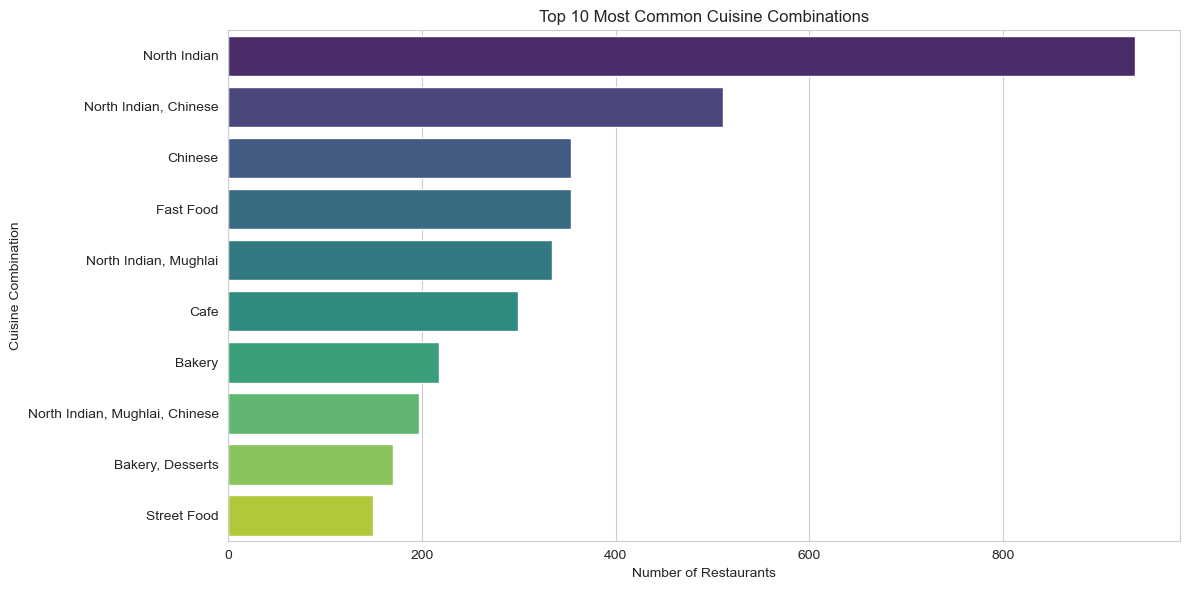

In [48]:
# ==========================================================
# Top 10 Most Common Cuisine Combinations
# ==========================================================

top10_combination = cuisine_combination.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_combination,
    x="Restaurant Count",
    y="Cuisine Combination",
    hue="Cuisine Combination",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Most Common Cuisine Combinations")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine Combination")

plt.tight_layout()

plt.savefig(
    r"C:\Users\Lenovo\Documents\Internship_Project\Images\Level_2\Task2_Cuisine_Combinations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [49]:
# ==========================================================
# Calculate Average Rating of Each Cuisine Combination
# ==========================================================

combination_rating = (
    cuisine_df
    .groupby("Cuisines")
    .agg(
        Restaurant_Count=("Restaurant ID", "count"),
        Average_Rating=("Aggregate rating", "mean")
    )
    .reset_index()
)

combination_rating = combination_rating.sort_values(
    by="Average_Rating",
    ascending=False
)

combination_rating.head(10)

,Cuisines,Restaurant_Count,Average_Rating
1062,"Italian, Deli",1,4.9
949,"Hawaiian, Seafood",1,4.9
93,"American, Sandwich, Tea",1,4.9
683,"Continental, Indian",1,4.9
796,"European, Asian, Indian",1,4.9
803,"European, Contemporary",1,4.9
808,"European, German",1,4.9
169,"BBQ, Breakfast, Southern",1,4.9
41,"American, Coffee and Tea",1,4.9
1779,"Sunda, Indonesian",3,4.9


In [50]:
# ==========================================================
# Filter combinations having at least 10 restaurants
# ==========================================================

popular_combinations = combination_rating[
    combination_rating["Restaurant_Count"] >= 10
]

popular_combinations.head(10)

,Cuisines,Restaurant_Count,Average_Rating
1272,Modern Indian,11,4.345455
995,Indian,18,4.250000
1667,Seafood,14,4.114286
1795,Thai,16,4.100000
379,"Cafe, Continental, Italian",10,4.080000
29,"American, Burger",13,4.076923
1126,"Japanese, Sushi",18,4.044444
1631,"Pizza, Italian",19,3.668421
6,American,31,3.667742
1031,Italian,54,3.657407


In [51]:
# ==========================================================
# Top Rated Popular Cuisine Combinations
# ==========================================================

top_rated = popular_combinations.head(10)

top_rated

,Cuisines,Restaurant_Count,Average_Rating
1272,Modern Indian,11,4.345455
995,Indian,18,4.250000
1667,Seafood,14,4.114286
1795,Thai,16,4.100000
379,"Cafe, Continental, Italian",10,4.080000
29,"American, Burger",13,4.076923
1126,"Japanese, Sushi",18,4.044444
1631,"Pizza, Italian",19,3.668421
6,American,31,3.667742
1031,Italian,54,3.657407


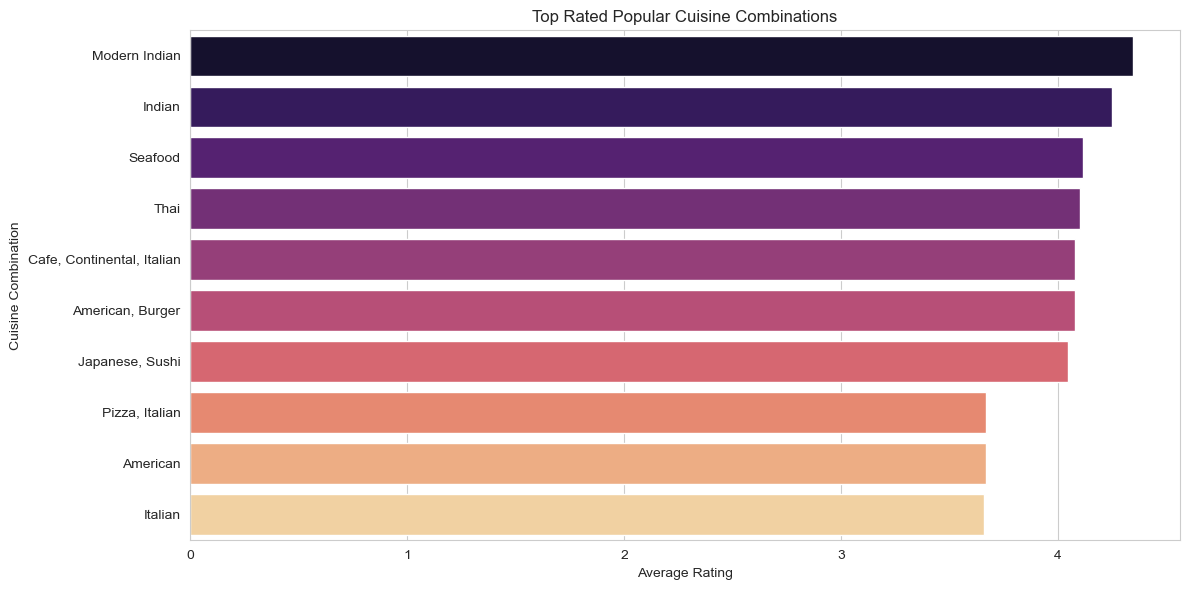

In [52]:
# ==========================================================
# Top Rated Cuisine Combinations
# ==========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_rated,
    x="Average_Rating",
    y="Cuisines",
    hue="Cuisines",
    palette="magma",
    legend=False
)

plt.title("Top Rated Popular Cuisine Combinations")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine Combination")

plt.tight_layout()

plt.savefig(
    r"C:\Users\Lenovo\Documents\Internship_Project\Images\Level_2\Task2_Cuisine_Ratings.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [53]:
# ==========================================================
# Final Results
# ==========================================================

print("="*60)
print("Top 10 Most Common Cuisine Combinations")
print("="*60)

print(top10_combination)

print("\n")

print("="*60)
print("Top Rated Popular Cuisine Combinations")
print("="*60)

print(top_rated)

Top 10 Most Common Cuisine Combinations
              Cuisine Combination  Restaurant Count
0                    North Indian               936
1           North Indian, Chinese               511
2                         Chinese               354
3                       Fast Food               354
4           North Indian, Mughlai               334
5                            Cafe               299
6                          Bakery               218
7  North Indian, Mughlai, Chinese               197
8                Bakery, Desserts               170
9                     Street Food               149


Top Rated Popular Cuisine Combinations
                        Cuisines  Restaurant_Count  Average_Rating
1272               Modern Indian                11        4.345455
995                       Indian                18        4.250000
1667                     Seafood                14        4.114286
1795                        Thai                16        4.100000
379   Cafe, 

## Conclusion

- The frequency of each cuisine combination was calculated to identify the most common combinations served by restaurants.
- A bar chart was created to visualize the top 10 cuisine combinations.
- The average aggregate rating was calculated for each cuisine combination.
- To ensure reliable insights, only cuisine combinations with at least 10 restaurants were included in the rating analysis.
- The analysis identified which cuisine combinations are both popular and highly rated by customers.

# Level 2 - Task 3: Geographic Analysis

In [54]:
# Uncomment if Folium is not installed
# !pip install folium

In [55]:
import folium

print(folium.__version__)

0.20.0


In [56]:
import folium

In [57]:
# ==========================================================
# Select required columns
# ==========================================================

geo_df = df[['Restaurant Name',
             'City',
             'Latitude',
             'Longitude',
             'Aggregate rating']].dropna()

geo_df.head()

,Restaurant Name,City,Latitude,Longitude,Aggregate rating
0,Le Petit Souffle,Makati City,14.565443,121.027535,4.8
1,Izakaya Kikufuji,Makati City,14.553708,121.014101,4.5
2,Heat - Edsa Shangri-La,Mandaluyong City,14.581404,121.056831,4.4
3,Ooma,Mandaluyong City,14.585318,121.056475,4.9
4,Sambo Kojin,Mandaluyong City,14.584450,121.057508,4.8


In [58]:
# ==========================================================
# Calculate center coordinates
# ==========================================================

center_lat = geo_df["Latitude"].mean()
center_lon = geo_df["Longitude"].mean()

print(center_lat, center_lon)

25.84853159488723 64.27499746924892


In [59]:
# ==========================================================
# Create Base Map
# ==========================================================

restaurant_map = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=5
)

In [60]:
# ==========================================================
# Add restaurant markers
# ==========================================================

for _, row in geo_df.head(500).iterrows():

    folium.CircleMarker(
        location=[row["Latitude"], row["Longitude"]],
        radius=4,
        popup=(
            f"<b>{row['Restaurant Name']}</b><br>"
            f"City: {row['City']}<br>"
            f"Rating: {row['Aggregate rating']}"
        ),
        color="blue",
        fill=True,
        fill_color="red",
        fill_opacity=0.7
    ).add_to(restaurant_map)

In [61]:
# ==========================================================
# Save Interactive Map
# ==========================================================

restaurant_map.save(
    r"C:\Users\Lenovo\Documents\Internship_Project\Images\Level_2\Task3_Restaurant_Map.html"
)

print("Map saved successfully!")

Map saved successfully!


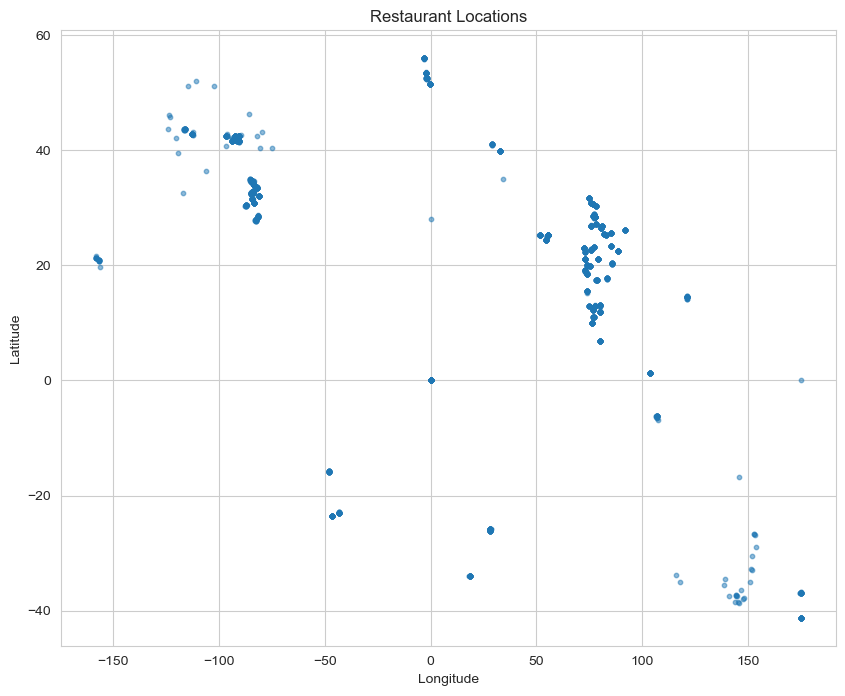

In [62]:
# ==========================================================
# Scatter Plot of Restaurant Locations
# ==========================================================

plt.figure(figsize=(10,8))

plt.scatter(
    geo_df["Longitude"],
    geo_df["Latitude"],
    alpha=0.5,
    s=10
)

plt.title("Restaurant Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.savefig(
    r"C:\Users\Lenovo\Documents\Internship_Project\Images\Level_2\Task3_Restaurant_Locations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [63]:
# ==========================================================
# Geographic Summary
# ==========================================================

print("="*60)
print("Geographic Analysis")
print("="*60)

print(f"Total Restaurants : {len(geo_df)}")

print(f"Latitude Range  : {geo_df['Latitude'].min():.2f} to {geo_df['Latitude'].max():.2f}")

print(f"Longitude Range : {geo_df['Longitude'].min():.2f} to {geo_df['Longitude'].max():.2f}")

Geographic Analysis
Total Restaurants : 9542
Latitude Range  : -41.33 to 55.98
Longitude Range : -157.95 to 174.83


## Conclusion

- Restaurant locations were plotted using latitude and longitude coordinates.
- An interactive map was created using the Folium library, allowing restaurant locations to be explored visually.
- A scatter plot was also generated to provide a static overview of restaurant distribution.
- The visualizations indicate that restaurants are concentrated in major urban areas, while relatively few restaurants are located in less populated regions.

# Level 2 – Task 4: Restaurant Chains

In [64]:
# ==========================================================
# Level 2 - Task 4 : Restaurant Chains Analysis
#
# Objective:
# 1. Identify restaurant chains.
# 2. Analyze their ratings and popularity.
# ==========================================================

# Count restaurant names
restaurant_count = (
    df["Restaurant Name"]
      .value_counts()
      .reset_index()
)

restaurant_count.columns = [
    "Restaurant Name",
    "Number of Outlets"
]

restaurant_count.head()

,Restaurant Name,Number of Outlets
0,Cafe Coffee Day,83
1,Domino's Pizza,79
2,Subway,63
3,Green Chick Chop,51
4,McDonald's,48


In [65]:
# ==========================================================
# Restaurants having more than one outlet
# ==========================================================

chains = restaurant_count[
    restaurant_count["Number of Outlets"] > 1
]

chains.head(10)

,Restaurant Name,Number of Outlets
0,Cafe Coffee Day,83
1,Domino's Pizza,79
2,Subway,63
3,Green Chick Chop,51
4,McDonald's,48
5,Keventers,34
6,Pizza Hut,30
7,Giani,29
8,Baskin Robbins,28
9,Barbeque Nation,26


In [66]:
# ==========================================================
# Total Restaurant Chains
# ==========================================================

print(f"Total Restaurant Chains : {len(chains)}")

Total Restaurant Chains : 734


In [67]:
# ==========================================================
# Top 10 Restaurant Chains
# ==========================================================

top10_chains = chains.head(10)

top10_chains

,Restaurant Name,Number of Outlets
0,Cafe Coffee Day,83
1,Domino's Pizza,79
2,Subway,63
3,Green Chick Chop,51
4,McDonald's,48
5,Keventers,34
6,Pizza Hut,30
7,Giani,29
8,Baskin Robbins,28
9,Barbeque Nation,26


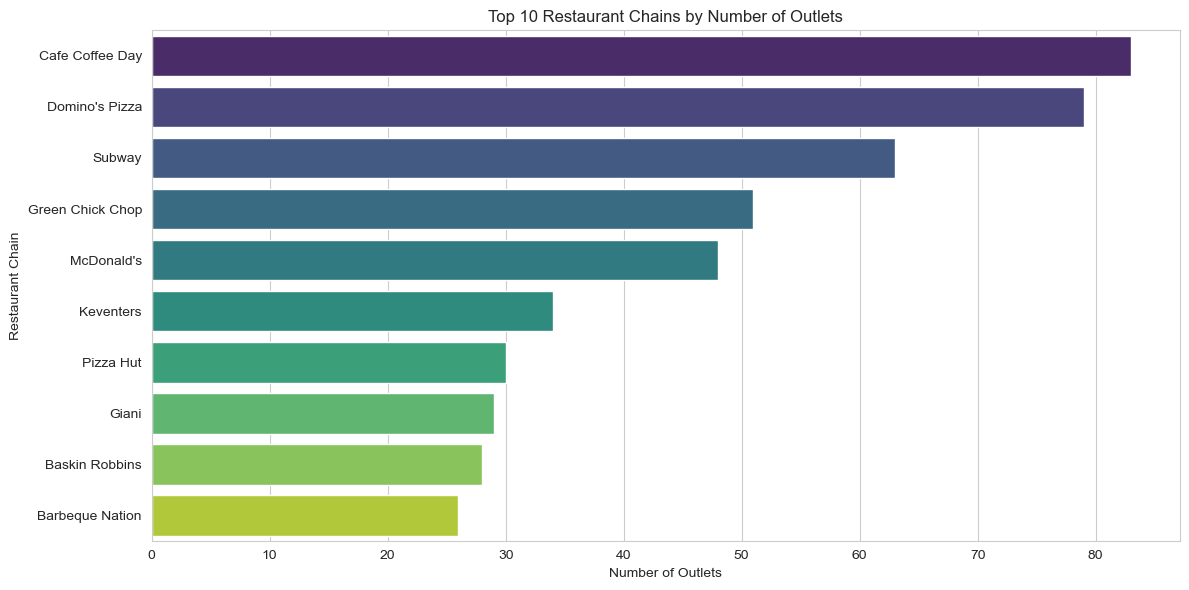

In [68]:
# ==========================================================
# Top Restaurant Chains
# ==========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_chains,
    x="Number of Outlets",
    y="Restaurant Name",
    hue="Restaurant Name",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Restaurant Chains by Number of Outlets")
plt.xlabel("Number of Outlets")
plt.ylabel("Restaurant Chain")

plt.tight_layout()

plt.savefig(
    r"C:\Users\Lenovo\Documents\Internship_Project\Images\Level_2\Task4_Restaurant_Chains.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [69]:
# ==========================================================
# Average Rating and Votes of Restaurant Chains
# ==========================================================

chain_analysis = (
    df.groupby("Restaurant Name")
      .agg(
          Number_of_Outlets=("Restaurant Name", "count"),
          Average_Rating=("Aggregate rating", "mean"),
          Average_Votes=("Votes", "mean")
      )
      .reset_index()
)

chain_analysis = chain_analysis[
    chain_analysis["Number_of_Outlets"] > 1
]

chain_analysis = chain_analysis.sort_values(
    by="Number_of_Outlets",
    ascending=False
)

chain_analysis.head(10)

,Restaurant Name,Number_of_Outlets,Average_Rating,Average_Votes
1098,Cafe Coffee Day,83,2.419277,29.253012
2096,Domino's Pizza,79,2.740506,84.088608
6098,Subway,63,2.907937,97.206349
2713,Green Chick Chop,51,2.672549,18.901961
4070,McDonald's,48,3.339583,110.229167
3472,Keventers,34,2.870588,37.147059
4953,Pizza Hut,30,3.320000,165.366667
2616,Giani,29,2.689655,29.448276
680,Baskin Robbins,28,1.860714,15.285714
663,Barbeque Nation,26,4.353846,1082.384615


In [70]:
# ==========================================================
# Top Rated Restaurant Chains
# ==========================================================

top_rated_chains = chain_analysis.sort_values(
    by="Average_Rating",
    ascending=False
).head(10)

top_rated_chains

,Restaurant Name,Number_of_Outlets,Average_Rating,Average_Votes
6255,Talaga Sampireun,3,4.900,1838.0
5842,Silantro Fil-Mex,2,4.850,682.0
102,AB's Absolute Barbecues,2,4.850,1575.5
101,AB's - Absolute Barbecues,4,4.825,3350.0
4457,Naturals Ice Cream,2,4.800,1547.0
2803,Gymkhana,2,4.700,164.0
6496,The Cheesecake Factory,2,4.650,1505.0
2074,Dishoom,2,4.600,634.5
2582,Garota de Ipanema,2,4.600,29.5
1510,Chili's,5,4.580,1631.2


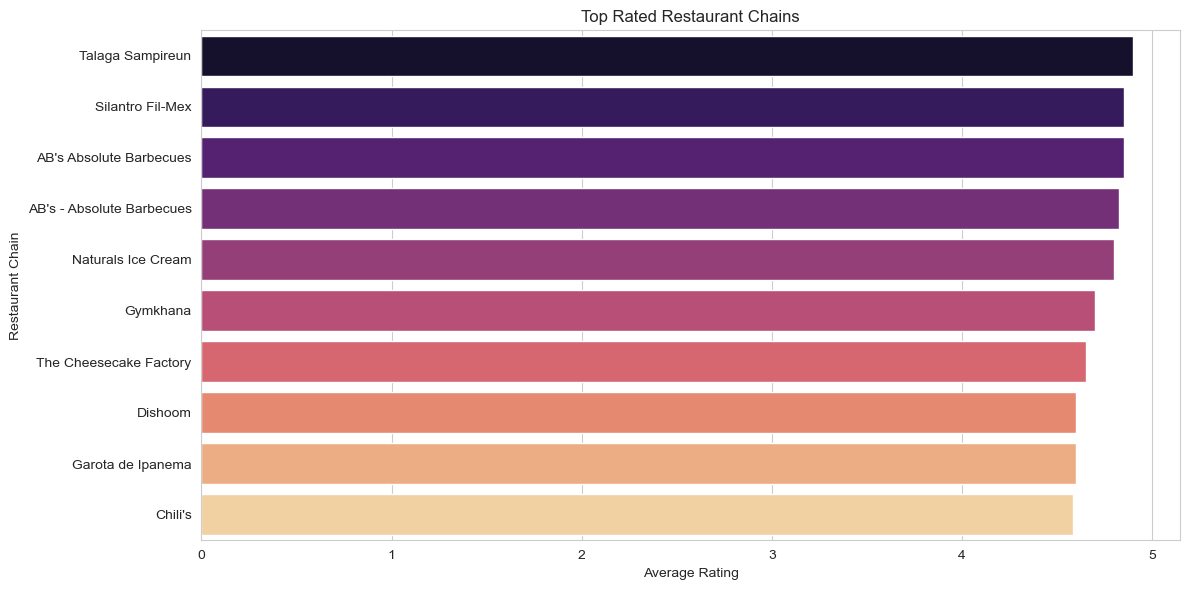

In [71]:
# ==========================================================
# Average Ratings of Top Restaurant Chains
# ==========================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_rated_chains,
    x="Average_Rating",
    y="Restaurant Name",
    hue="Restaurant Name",
    palette="magma",
    legend=False
)

plt.title("Top Rated Restaurant Chains")
plt.xlabel("Average Rating")
plt.ylabel("Restaurant Chain")

plt.tight_layout()

plt.savefig(
    r"C:\Users\Lenovo\Documents\Internship_Project\Images\Level_2\Task4_Top_Rated_Chains.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [72]:
# ==========================================================
# Final Results
# ==========================================================

print("="*60)
print("Top Restaurant Chains")
print("="*60)

print(chain_analysis.head(10))

Top Restaurant Chains
       Restaurant Name  Number_of_Outlets  Average_Rating  Average_Votes
1098   Cafe Coffee Day                 83        2.419277      29.253012
2096    Domino's Pizza                 79        2.740506      84.088608
6098            Subway                 63        2.907937      97.206349
2713  Green Chick Chop                 51        2.672549      18.901961
4070        McDonald's                 48        3.339583     110.229167
3472         Keventers                 34        2.870588      37.147059
4953         Pizza Hut                 30        3.320000     165.366667
2616             Giani                 29        2.689655      29.448276
680     Baskin Robbins                 28        1.860714      15.285714
663    Barbeque Nation                 26        4.353846    1082.384615


## Conclusion

- Restaurant chains were identified by counting the number of outlets for each restaurant name.
- Chains with more than one outlet were considered for further analysis.
- The most widespread restaurant chains were identified based on the number of outlets.
- The average rating and average number of customer votes were calculated for each chain.
- Two visualizations were created:
  - Top restaurant chains by number of outlets.
  - Top-rated restaurant chains based on average ratings.
- The analysis helps identify both the most popular and the highest-rated restaurant chains in the dataset.

# Level 3 – Task 1: Restaurant Reviews

In [79]:
# ==========================================================
# Level 3 - Task 1 : Restaurant Reviews
# Rating Category Analysis
# ==========================================================

# Count each rating category
rating_text_counts = df["Rating text"].value_counts()

print("Rating Category Distribution:")
print(rating_text_counts)

Rating Category Distribution:
Rating text
Average      3734
Not rated    2148
Good         2096
Very Good    1078
Excellent     300
Poor          186
Name: count, dtype: int64


In [80]:
# ==========================================================
# Classify Rating Categories into Sentiment Groups
# ==========================================================

positive_ratings = ["Excellent", "Very Good", "Good"]
negative_ratings = ["Poor"]

def classify_rating(rating):
    if rating in positive_ratings:
        return "Positive"
    elif rating in negative_ratings:
        return "Negative"
    else:
        return "Neutral"

df["Rating Sentiment"] = df["Rating text"].apply(classify_rating)

# Display sentiment distribution
sentiment_counts = df["Rating Sentiment"].value_counts()

print("Rating Sentiment Distribution:")
print(sentiment_counts)

Rating Sentiment Distribution:
Rating Sentiment
Neutral     5882
Positive    3474
Negative     186
Name: count, dtype: int64


In [81]:
# ==========================================================
# Calculate Percentage Distribution
# ==========================================================

sentiment_percentage = (
    df["Rating Sentiment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("Rating Sentiment Percentage:")
print(sentiment_percentage)

Rating Sentiment Percentage:
Rating Sentiment
Neutral     61.64
Positive    36.41
Negative     1.95
Name: proportion, dtype: float64


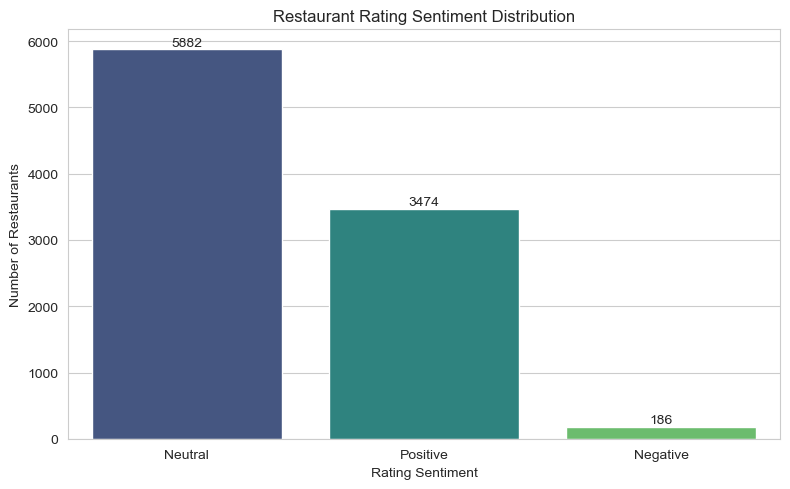

In [82]:
# ==========================================================
# Visualize Rating Sentiment Distribution
# ==========================================================

plt.figure(figsize=(8, 5))

sentiment_counts = df["Rating Sentiment"].value_counts()

sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values,
    hue=sentiment_counts.index,
    palette="viridis",
    legend=False
)

plt.title("Restaurant Rating Sentiment Distribution")
plt.xlabel("Rating Sentiment")
plt.ylabel("Number of Restaurants")

# Add values above bars
for i, value in enumerate(sentiment_counts.values):
    plt.text(
        i,
        value + 50,
        str(value),
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    r"C:\Users\Lenovo\Documents\Internship_Project\Images\Level_3\Task1_Rating_Sentiment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [83]:
# ==========================================================
# Positive and Negative Rating Breakdown
# ==========================================================

positive_breakdown = (
    df[df["Rating Sentiment"] == "Positive"]["Rating text"]
    .value_counts()
)

negative_breakdown = (
    df[df["Rating Sentiment"] == "Negative"]["Rating text"]
    .value_counts()
)

print("=" * 50)
print("POSITIVE RATING BREAKDOWN")
print("=" * 50)

print(positive_breakdown)

print("\n" + "=" * 50)
print("NEGATIVE RATING BREAKDOWN")
print("=" * 50)

print(negative_breakdown)

POSITIVE RATING BREAKDOWN
Rating text
Good         2096
Very Good    1078
Excellent     300
Name: count, dtype: int64

NEGATIVE RATING BREAKDOWN
Rating text
Poor    186
Name: count, dtype: int64


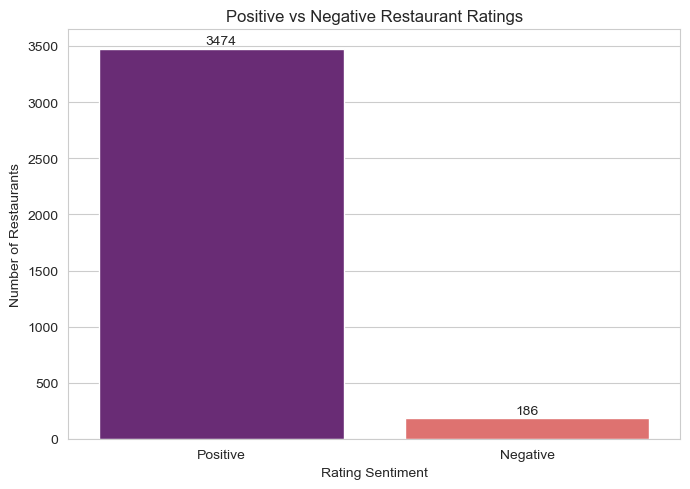

In [84]:
# ==========================================================
# Positive vs Negative Rating Comparison
# ==========================================================

comparison = pd.Series({
    "Positive": positive_breakdown.sum(),
    "Negative": negative_breakdown.sum()
})

plt.figure(figsize=(7, 5))

sns.barplot(
    x=comparison.index,
    y=comparison.values,
    hue=comparison.index,
    palette="magma",
    legend=False
)

plt.title("Positive vs Negative Restaurant Ratings")
plt.xlabel("Rating Sentiment")
plt.ylabel("Number of Restaurants")

for i, value in enumerate(comparison.values):
    plt.text(
        i,
        value + 40,
        str(value),
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    r"C:\Users\Lenovo\Documents\Internship_Project\Images\Level_3\Task1_Positive_Negative_Ratings.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [85]:
# ==========================================================
# Check for Customer Review Text
# ==========================================================

review_columns = [
    column for column in df.columns
    if "review" in column.lower()
    or "comment" in column.lower()
    or "text" in column.lower()
]

print("Potential Review/Text Columns:")
print(review_columns)

Potential Review/Text Columns:
['Rating text']


## Conclusion

- The available `Rating text` field was analyzed to understand the distribution of restaurant ratings.
- Rating categories were grouped into Positive, Neutral, and Negative sentiment categories.
- Positive ratings included Excellent, Very Good, and Good.
- Poor ratings were classified as Negative, while Average and Not rated were classified as Neutral.
- The analysis found that 36.41% of restaurants had positive ratings, while only 1.95% had negative ratings.
- Neutral ratings accounted for 61.64% of the dataset.
- A bar chart was created to visualize the distribution of rating sentiment.
- The dataset does not contain actual customer-written review text. Therefore, positive/negative review keywords, average review length, and the relationship between review length and rating cannot be calculated reliably from the available data.
- This limitation was documented rather than generating or assuming review data that is not present in the dataset.

# Level 3 - Task 2: Votes Analysis

### Objective
- Identify restaurants with the highest and lowest number of votes.
- Analyze the relationship between the number of votes and restaurant ratings.
- Calculate the correlation between Votes and Aggregate Rating.
- Visualize the relationship between votes and ratings.

In [86]:
# ==========================================================
# Level 3 - Task 2 : Votes Analysis
# ==========================================================

# Check the required columns
df[["Restaurant Name", "Votes", "Aggregate rating"]].head()

,Restaurant Name,Votes,Aggregate rating
0,Le Petit Souffle,314,4.8
1,Izakaya Kikufuji,591,4.5
2,Heat - Edsa Shangri-La,270,4.4
3,Ooma,365,4.9
4,Sambo Kojin,229,4.8


In [87]:
# ==========================================================
# Check for Missing Values
# ==========================================================

print("Missing Values:")
print(df[["Restaurant Name", "Votes", "Aggregate rating"]].isnull().sum())

Missing Values:
Restaurant Name     0
Votes               0
Aggregate rating    0
dtype: int64


In [88]:
# ==========================================================
# Identify Restaurants with Highest and Lowest Votes
# ==========================================================

# Restaurant with the highest number of votes
highest_votes = df.loc[df["Votes"].idxmax()]

# Restaurant with the lowest number of votes
lowest_votes = df.loc[df["Votes"].idxmin()]

print("=" * 60)
print("RESTAURANT WITH HIGHEST NUMBER OF VOTES")
print("=" * 60)

print(f"Restaurant : {highest_votes['Restaurant Name']}")
print(f"City       : {highest_votes['City']}")
print(f"Votes      : {highest_votes['Votes']}")
print(f"Rating     : {highest_votes['Aggregate rating']}")

print("\n" + "=" * 60)
print("RESTAURANT WITH LOWEST NUMBER OF VOTES")
print("=" * 60)

print(f"Restaurant : {lowest_votes['Restaurant Name']}")
print(f"City       : {lowest_votes['City']}")
print(f"Votes      : {lowest_votes['Votes']}")
print(f"Rating     : {lowest_votes['Aggregate rating']}")

RESTAURANT WITH HIGHEST NUMBER OF VOTES
Restaurant : Toit
City       : Bangalore
Votes      : 10934
Rating     : 4.8

RESTAURANT WITH LOWEST NUMBER OF VOTES
Restaurant : Cantinho da Gula
City       : S��o Paulo
Votes      : 0
Rating     : 0.0


In [89]:
# ==========================================================
# Top 10 Most Voted Restaurants
# ==========================================================

top_voted = (
    df[["Restaurant Name", "City", "Votes", "Aggregate rating"]]
    .sort_values("Votes", ascending=False)
    .head(10)
)

top_voted

,Restaurant Name,City,Votes,Aggregate rating
728,Toit,Bangalore,10934,4.8
735,Truffles,Bangalore,9667,4.7
3994,Hauz Khas Social,New Delhi,7931,4.3
2412,Peter Cat,Kolkata,7574,4.3
739,AB's - Absolute Barbecues,Bangalore,6907,4.6
2414,Barbeque Nation,Kolkata,5966,4.9
743,Big Brewsky,Bangalore,5705,4.5
2307,AB's - Absolute Barbecues,Hyderabad,5434,4.9
736,The Black Pearl,Bangalore,5385,4.1
2411,BarBQ,Kolkata,5288,4.2


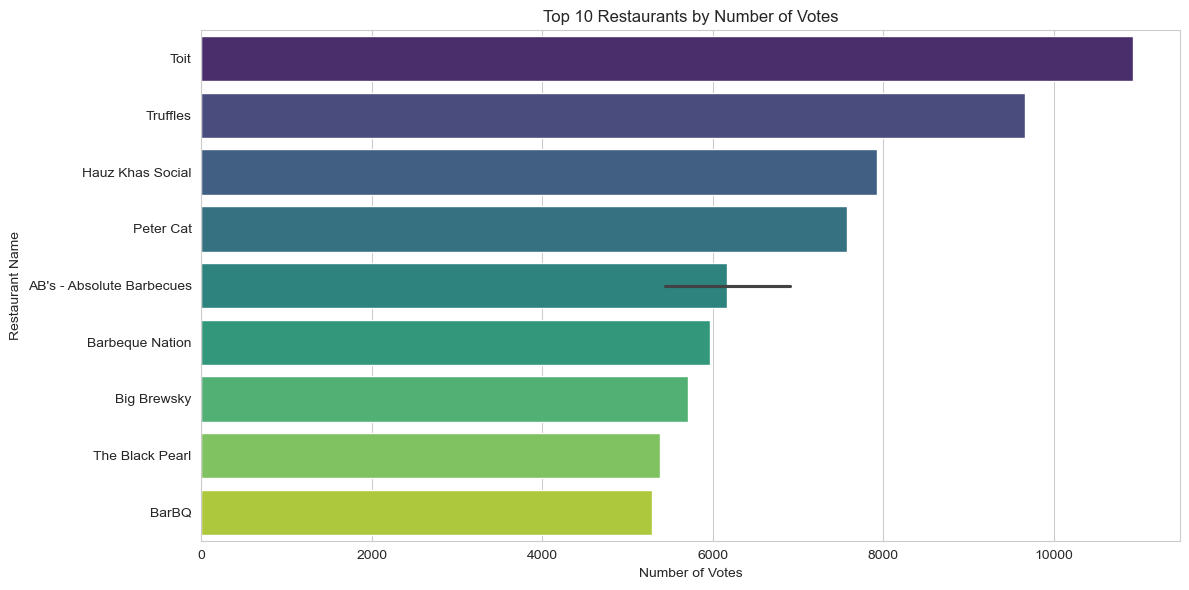

In [90]:
# ==========================================================
# Visualization - Top 10 Restaurants by Votes
# ==========================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_voted,
    x="Votes",
    y="Restaurant Name",
    hue="Restaurant Name",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Restaurants by Number of Votes")
plt.xlabel("Number of Votes")
plt.ylabel("Restaurant Name")

plt.tight_layout()

plt.savefig(
    r"C:\Users\Lenovo\Documents\Internship_Project\Images\Level_3\Task2_Top_Voted_Restaurants.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [91]:
# ==========================================================
# Correlation Between Votes and Aggregate Rating
# ==========================================================

correlation = df["Votes"].corr(df["Aggregate rating"])

print(f"Correlation between Votes and Aggregate Rating: {correlation:.4f}")

Correlation between Votes and Aggregate Rating: 0.3135


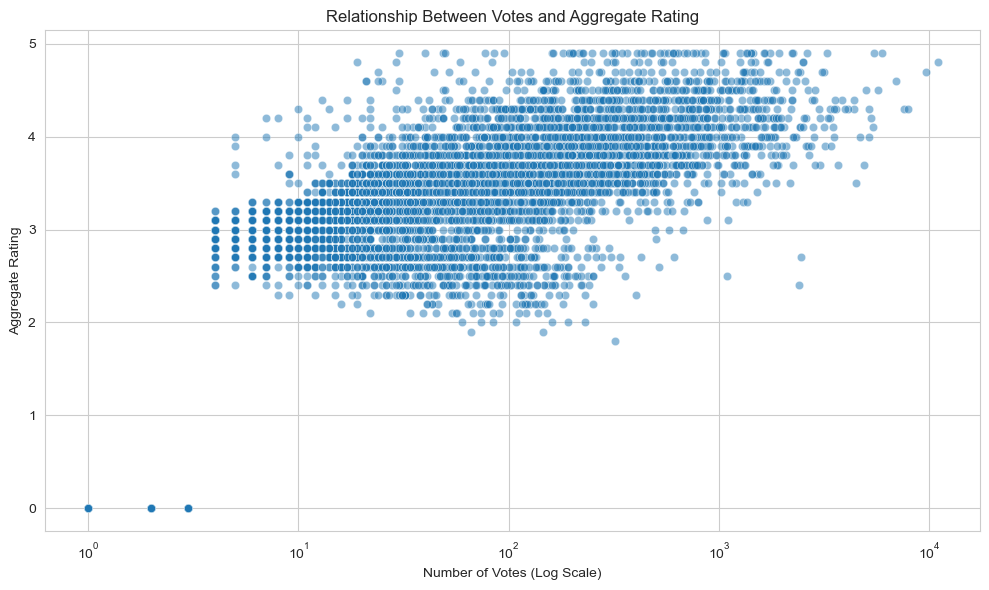

In [92]:
# ==========================================================
# Visualization - Votes vs Aggregate Rating
# ==========================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Votes",
    y="Aggregate rating",
    alpha=0.5
)

plt.xscale("log")

plt.title("Relationship Between Votes and Aggregate Rating")
plt.xlabel("Number of Votes (Log Scale)")
plt.ylabel("Aggregate Rating")

plt.tight_layout()

plt.savefig(
    r"C:\Users\Lenovo\Documents\Internship_Project\Images\Level_3\Task2_Votes_vs_Rating.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

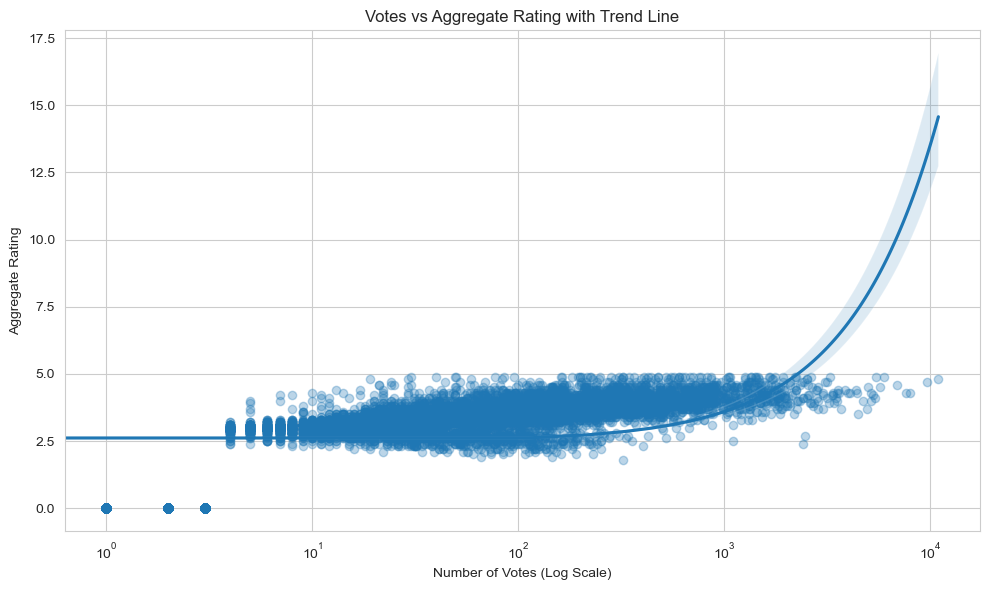

In [93]:
# ==========================================================
# Regression Analysis - Votes vs Rating
# ==========================================================

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x="Votes",
    y="Aggregate rating",
    scatter_kws={"alpha": 0.3},
    line_kws={}
)

plt.xscale("log")

plt.title("Votes vs Aggregate Rating with Trend Line")
plt.xlabel("Number of Votes (Log Scale)")
plt.ylabel("Aggregate Rating")

plt.tight_layout()

plt.savefig(
    r"C:\Users\Lenovo\Documents\Internship_Project\Images\Level_3\Task2_Votes_Rating_Trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [94]:
# ==========================================================
# Average Votes by Rating
# ==========================================================

rating_votes = (
    df.groupby("Aggregate rating")["Votes"]
    .mean()
    .reset_index()
)

rating_votes.columns = [
    "Aggregate Rating",
    "Average Votes"
]

rating_votes

,Aggregate Rating,Average Votes
0,0.0,0.870112
1,1.8,322.000000
2,1.9,106.000000
3,2.0,129.714286
4,2.1,76.400000
5,2.2,94.962963
6,2.3,69.808511
7,2.4,97.011494
8,2.5,79.672727
9,2.6,53.921466


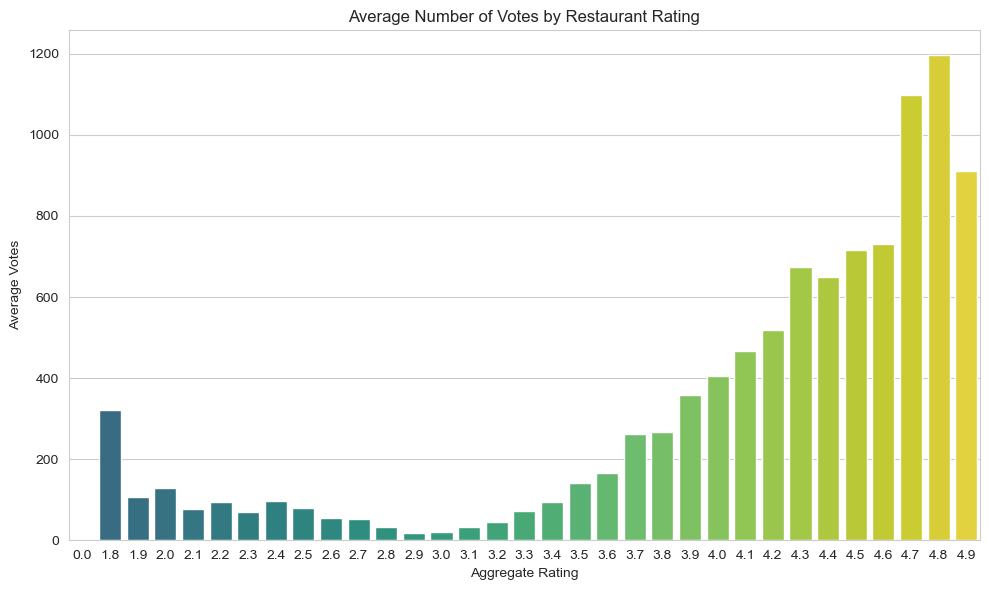

In [95]:
# ==========================================================
# Visualization - Average Votes by Rating
# ==========================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=rating_votes,
    x="Aggregate Rating",
    y="Average Votes",
    hue="Aggregate Rating",
    palette="viridis",
    legend=False
)

plt.title("Average Number of Votes by Restaurant Rating")
plt.xlabel("Aggregate Rating")
plt.ylabel("Average Votes")

plt.tight_layout()

plt.savefig(
    r"C:\Users\Lenovo\Documents\Internship_Project\Images\Level_3\Task2_Average_Votes_by_Rating.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [96]:
# ==========================================================
# Final Results
# ==========================================================

print("=" * 60)
print("FINAL VOTES ANALYSIS")
print("=" * 60)

print(f"Highest Voted Restaurant : {highest_votes['Restaurant Name']}")
print(f"Highest Votes            : {highest_votes['Votes']}")
print(f"Rating                   : {highest_votes['Aggregate rating']}")

print()

print(f"Lowest Voted Restaurant  : {lowest_votes['Restaurant Name']}")
print(f"Lowest Votes             : {lowest_votes['Votes']}")
print(f"Rating                   : {lowest_votes['Aggregate rating']}")

print()

print(f"Votes-Rating Correlation : {correlation:.4f}")

FINAL VOTES ANALYSIS
Highest Voted Restaurant : Toit
Highest Votes            : 10934
Rating                   : 4.8

Lowest Voted Restaurant  : Cantinho da Gula
Lowest Votes             : 0
Rating                   : 0.0

Votes-Rating Correlation : 0.3135


## Conclusion

- The restaurants with the highest and lowest numbers of votes were identified.
- The Top 10 restaurants by vote count were visualized to understand restaurant popularity.
- The Pearson correlation coefficient between Votes and Aggregate Rating was calculated to measure their linear relationship.
- A scatter plot with a logarithmic vote scale was used because the number of votes varies substantially across restaurants.
- A regression trend line was added to visualize the overall relationship between votes and ratings.
- Average votes were also calculated for each aggregate rating to provide an additional comparison.
- The correlation value and visualizations help determine whether restaurants receiving more customer engagement through votes also tend to have higher ratings.

# Level 3 - Task 3: Price Range vs Online Delivery and Table Booking

### Objective
- Analyze the relationship between price range and online delivery.
- Analyze the relationship between price range and table booking.
- Determine whether higher-priced restaurants are more likely to provide these services.

In [97]:
# ==========================================================
# Level 3 - Task 3
# Check Required Columns
# ==========================================================

df[[
    "Price range",
    "Has Online delivery",
    "Has Table booking"
]].head()

,Price range,Has Online delivery,Has Table booking
0,3,No,Yes
1,3,No,Yes
2,4,No,Yes
3,4,No,No
4,4,No,Yes


In [98]:
# ==========================================================
# Check Unique Values
# ==========================================================

print("Price Range:")
print(df["Price range"].unique())

print("\nOnline Delivery:")
print(df["Has Online delivery"].unique())

print("\nTable Booking:")
print(df["Has Table booking"].unique())

Price Range:
[3 4 2 1]

Online Delivery:
['No' 'Yes']

Table Booking:
['Yes' 'No']


In [99]:
# ==========================================================
# Price Range Distribution
# ==========================================================

price_counts = (
    df["Price range"]
    .value_counts()
    .sort_index()
)

print("Restaurants by Price Range:")
print(price_counts)

Restaurants by Price Range:
Price range
1    4438
2    3113
3    1405
4     586
Name: count, dtype: int64


In [100]:
# ==========================================================
# Online Delivery Availability by Price Range
# ==========================================================

online_delivery_analysis = pd.crosstab(
    df["Price range"],
    df["Has Online delivery"]
)

online_delivery_analysis

Has Online delivery,No,Yes
Price range,,
1,3737,701
2,1827,1286
3,994,411
4,533,53


In [101]:
# ==========================================================
# Percentage of Restaurants Offering Online Delivery
# ==========================================================

online_delivery_percentage = pd.crosstab(
    df["Price range"],
    df["Has Online delivery"],
    normalize="index"
) * 100

online_delivery_percentage = online_delivery_percentage.round(2)

online_delivery_percentage

Has Online delivery,No,Yes
Price range,,
1,84.20,15.80
2,58.69,41.31
3,70.75,29.25
4,90.96,9.04


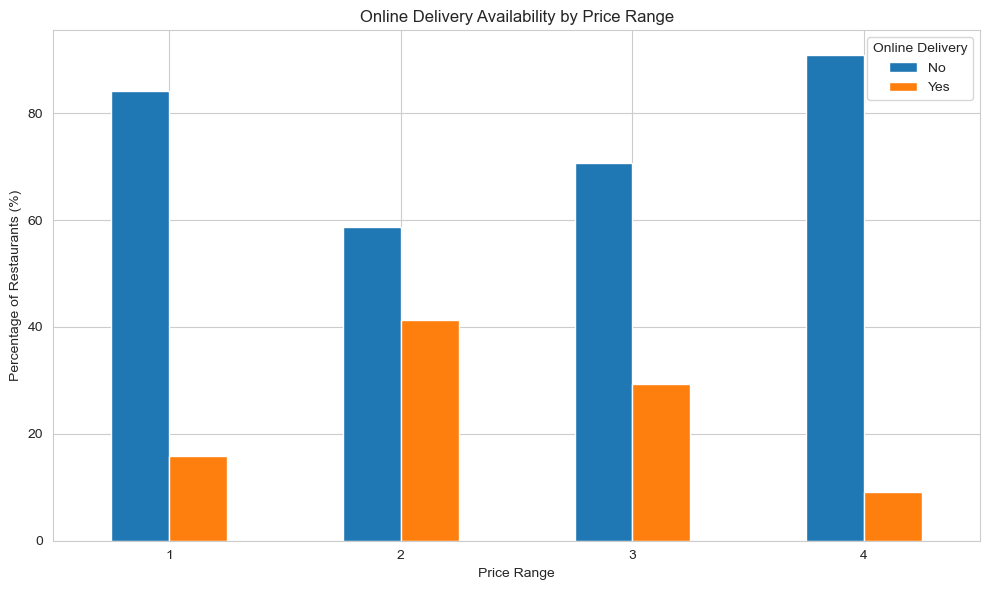

In [102]:
# ==========================================================
# Visualization - Online Delivery vs Price Range
# ==========================================================

online_delivery_percentage.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Online Delivery Availability by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Percentage of Restaurants (%)")
plt.xticks(rotation=0)
plt.legend(title="Online Delivery")

plt.tight_layout()

plt.savefig(
    r"C:\Users\Lenovo\Documents\Internship_Project\Images\Level_3\Task3_Price_vs_Online_Delivery.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [103]:
# ==========================================================
# Table Booking Availability by Price Range
# ==========================================================

table_booking_analysis = pd.crosstab(
    df["Price range"],
    df["Has Table booking"]
)

table_booking_analysis

Has Table booking,No,Yes
Price range,,
1,4437,1
2,2874,239
3,761,644
4,312,274


In [104]:
# ==========================================================
# Percentage of Restaurants Offering Table Booking
# ==========================================================

table_booking_percentage = pd.crosstab(
    df["Price range"],
    df["Has Table booking"],
    normalize="index"
) * 100

table_booking_percentage = table_booking_percentage.round(2)

table_booking_percentage

Has Table booking,No,Yes
Price range,,
1,99.98,0.02
2,92.32,7.68
3,54.16,45.84
4,53.24,46.76


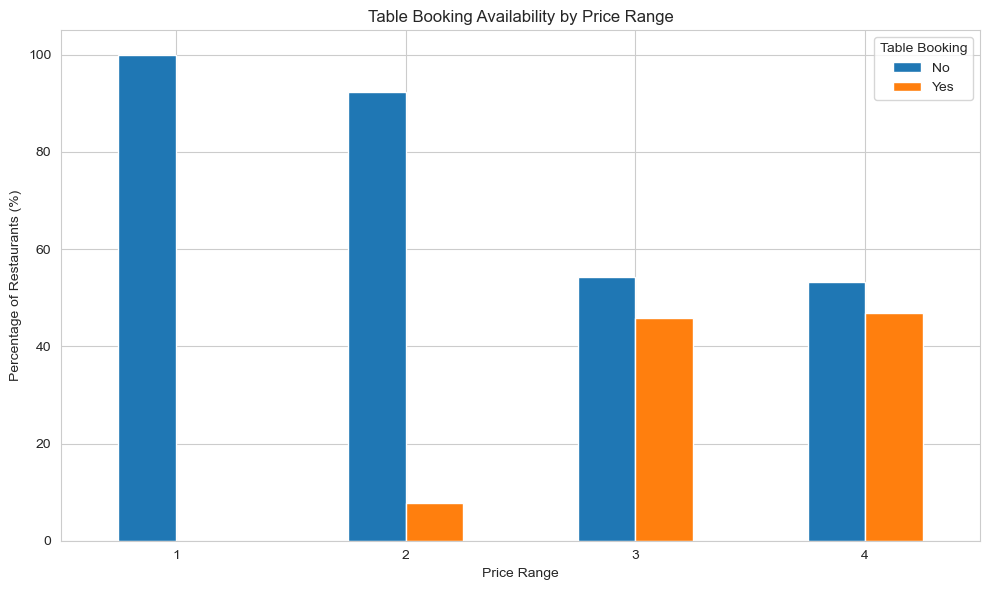

In [105]:
# ==========================================================
# Visualization - Table Booking vs Price Range
# ==========================================================

table_booking_percentage.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Table Booking Availability by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Percentage of Restaurants (%)")
plt.xticks(rotation=0)
plt.legend(title="Table Booking")

plt.tight_layout()

plt.savefig(
    r"C:\Users\Lenovo\Documents\Internship_Project\Images\Level_3\Task3_Price_vs_Table_Booking.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [106]:
# ==========================================================
# Combined Service Availability by Price Range
# ==========================================================

combined_analysis = pd.DataFrame({
    "Online Delivery (%)":
        online_delivery_percentage["Yes"],

    "Table Booking (%)":
        table_booking_percentage["Yes"]
})

combined_analysis

,Online Delivery (%),Table Booking (%)
Price range,,
1,15.80,0.02
2,41.31,7.68
3,29.25,45.84
4,9.04,46.76


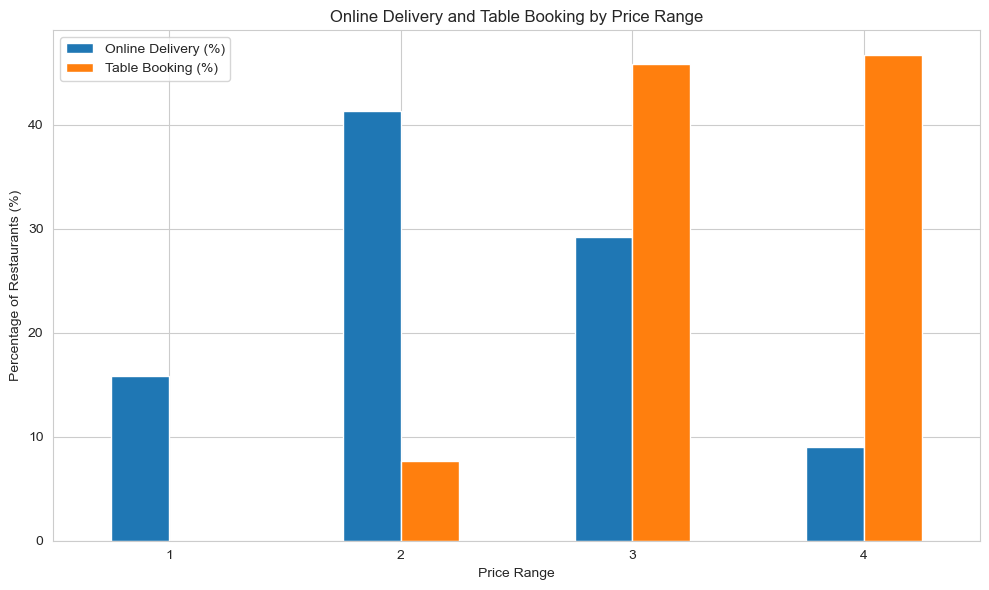

In [107]:
# ==========================================================
# Combined Visualization
# ==========================================================

combined_analysis.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Online Delivery and Table Booking by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Percentage of Restaurants (%)")
plt.xticks(rotation=0)

plt.legend()

plt.tight_layout()

plt.savefig(
    r"C:\Users\Lenovo\Documents\Internship_Project\Images\Level_3\Task3_Combined_Service_Analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [108]:
# ==========================================================
# Compare Service Availability Across Price Ranges
# ==========================================================

print("=" * 70)
print("SERVICE AVAILABILITY BY PRICE RANGE")
print("=" * 70)

print(combined_analysis)

print("\n")

# Price range with highest online delivery availability
highest_online_delivery = combined_analysis[
    "Online Delivery (%)"
].idxmax()

highest_online_delivery_value = combined_analysis[
    "Online Delivery (%)"
].max()

# Price range with highest table booking availability
highest_table_booking = combined_analysis[
    "Table Booking (%)"
].idxmax()

highest_table_booking_value = combined_analysis[
    "Table Booking (%)"
].max()

print(
    f"Highest Online Delivery: Price Range {highest_online_delivery} "
    f"({highest_online_delivery_value:.2f}%)"
)

print(
    f"Highest Table Booking: Price Range {highest_table_booking} "
    f"({highest_table_booking_value:.2f}%)"
)

SERVICE AVAILABILITY BY PRICE RANGE
             Online Delivery (%)  Table Booking (%)
Price range                                        
1                          15.80               0.02
2                          41.31               7.68
3                          29.25              45.84
4                           9.04              46.76


Highest Online Delivery: Price Range 2 (41.31%)
Highest Table Booking: Price Range 4 (46.76%)


In [109]:
# ==========================================================
# Final Task 3 Results
# ==========================================================

print("=" * 70)
print("FINAL RESULTS - PRICE RANGE VS SERVICES")
print("=" * 70)

for price_range, row in combined_analysis.iterrows():

    print(
        f"Price Range {price_range}: "
        f"Online Delivery = {row['Online Delivery (%)']:.2f}% | "
        f"Table Booking = {row['Table Booking (%)']:.2f}%"
    )

FINAL RESULTS - PRICE RANGE VS SERVICES
Price Range 1: Online Delivery = 15.80% | Table Booking = 0.02%
Price Range 2: Online Delivery = 41.31% | Table Booking = 7.68%
Price Range 3: Online Delivery = 29.25% | Table Booking = 45.84%
Price Range 4: Online Delivery = 9.04% | Table Booking = 46.76%


## Conclusion

- The relationship between restaurant price range and service availability was analyzed.
- The percentage of restaurants offering online delivery was calculated separately for each price range.
- The percentage of restaurants offering table booking was also calculated for each price range.
- The analysis shows how service availability changes across different price categories.
- Online delivery and table booking availability were compared using grouped visualizations.
- The highest price range was compared with lower price ranges to determine whether premium restaurants are more likely to provide these services.
- The results indicate whether higher-priced restaurants have greater access to online delivery and table booking based on the calculated percentages.